### Priorities: 
-- run through all places to refresh the normalisation stats
-- implement a change detection akin to SDG expectations. Compare before/after for WQ parameters and use SDG parameter names
-- implement water area stats in 



### Objective: Demonstrate workflow to characterise a waterbody in terms of its water quality based on the Geomedian data

#### Step 1. Defining the spatio-temporal extent - capabilities required here, to import the waterbody as a grid
Test on waterbodies that differ in geographic location, dynamics / climate, size, availabilty of data (richness of the wofs dataset and reliability of the geomedians)

More to do: Multiple polygons; using a waterbody as a reference area

#### Step 2. Data
##### 2.1 Extraction of Geomedian, WOFS and other data
- More to do: surface temperature

##### 2.2 Data preparation 
- Masking to water area, Rayleigh Correction (dark-pixel subtraction)
- More to do: work out a monthly time-series,  trimming of outliers; data smoothing / splines

##### 2.3 Data harmonisation - selection / application of Sentinel-Landsat harmonisation coefficients
- Harmonisation at the data level is not productive at this point

#### Step 3. Analysis
- 3.1 Colour transformation -  For MSI; not sure it's needed beyond that
- 3.2 FAI calculation and thresholding **to do**
- 3.3 Optical Water Type identification **done, with Oli and MSI** Oli results are not as stable; might be worth trying ETM **uses too much memory, need to use a resampled subset of the area**
- 3.4 Chl-A models        **implemented and harmonised** Extending to ETM to give time series depth.
- 3.5 Suspended material models **implemented and harmonised** Extending to ETM to give time series depth
- 3.6 Temperature 

#### 4. Summarise results per waterbody **implemented for the map extent** But not for the waterbody per se. 
##### 4.1 Graph the results... **can do rudimentary graphs**, and temporal interpolation for smoothing

#### 5. Export results as a persistent table (and other?)

#### Future objectives:
##### F1. Provide a comparison of Geomedian -> NDCI, with timeseries -> NDCI -> geomedian. 

    (1) Generate a series of indices from input data as a time-series
    (2) Summarise the time-series as a median 
    (3)Compare the median index with the geomedian-index 
    (4) Discuss differences and the advantages of using the Geomeian
    (5) publish
  

#### Load packages

In [1]:
import os
os.environ['USE_PYGEOS'] = '0'  #needed for polygons ...

import datacube
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd #one of the plotting help pages says this is needed
import gc
import json

from deafrica_tools.plotting import rgb
from deafrica_tools.app import geomedian
from scipy import stats


In [2]:
dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [3]:
%ls ../dev/deafrica_water_quality/WP1.2

'WQ package 1.2.ipynb'             _WQ_functions.py
 _Build_annual_dataset-1.0.ipynb   dummy.md


#### Add in useful functions

In [4]:
#these are now redundant -- mostly --- not all functions are included in the WP1.2 code

%run _AL_functions.ipynb             #import R_correction, rename_vars_robust,hue_adjust,hue_calculation
#%run _Space-time.py               #import set_spacetime_domain
#%run _Build_annual_dataset-1.0.ipynb  #functions to build the multivariate/multiinstrument dataset
#%run _OpticalWaterType.ipynb import OWT                #moved into AL_functions
#%run _WQ_measures.ipynb       #import NDCI_NIR_R ChlA_MERIS2B ChlA_MODIS2B


Loading AL_functions


In [5]:
# these functions should take priority over those defined in the above
%run ../dev/deafrica_water_quality/WP1.2/_WQ_functions.py
%run ../dev/deafrica_water_quality/WP1.2/_Build_annual_dataset-1.0.ipynb
#set_spacetime_domain()

In [6]:
#set which instruments to use (this is checked later against the date range for each place)
#for Phase1, mapping, the main datasets are the geomedians. For monioring the local time-seres will be brought in as well as the geomedians.

_instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False },  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': True },
    }

In [7]:
gc.collect()

27

In [8]:
places_dict     = set_spacetime_domain()   #gets the dictionary of places for analysis
reprocess_all   = False   #force  re-processing of all placesinitialise_results_file = False #use this to clear out the results file and start again.
verbose         = False
test            = False
_init           = False
water_frequency_threshold = \
water_frequency_threshold_high = 0.9   #this threshold might need to be relaxed for areas where there is much cloudy data.
#for pixel processing (rather than during summation), we will want to be more inclusive so that, for instance, total water area can be esimtated. A separate threshold is needed for that
water_frequency_threshold_low = 0.1
max_cells = 100000   #use this to test memory limits. Memory saving steps are going to be needed...
summary_filename    = 'wq_summary.nc'
wq_stats_filename   = 'wq_reference_stats.nc'
nparams_filename    = 'wq_normalisation_parameters.nc'
wq_summary_filename = 'tss_chla_summary.nc'
ds_save_file        = 'datasetsaved.nc'
places_filename     = 'places.json'
water_area_filename = 'water_area_results.txt'
#ds = summary= {}

In [9]:
places_dict.keys()

dict_keys(['Lake_Baringo', 'Lake_Chad', 'Weija_Reservoir', 'Senegal_StLouis', 'Lake_Sulunga', 'few_pixels', 'small_area', 'cameroon_res1', 'Lake_Victoria', 'Lake_Mweru', 'Lake_Mweru_subset', 'Ghana_AwunaBeach', 'Ghana_River', 'Large_area', 'Lake_vic_west', 'Lake_vic_east', 'Lake_vic_test', 'Lake_vic_turbid', 'Lake_vic_clear', 'Lake_Victoria_NE', 'Morocco', 'Thewaterskool_SA', 'SA_dam', 'SA_dam_north', 'SA_dam_south', 'Ethiopia1of2', 'Ethiopia2of2', 'Ethiopia3of2', 'Ethiopia_Lake_Tana', 'Mare_aux_Vacoas', 'SA_smalldam', 'Ethiopia_both', 'Madagascar', 'Lake_Manyara', 'Farihy_', 'Farihy_itasy', 'Kolokonda', 'Dodoma_small', 'size_test', 'lake_vic_all', 'lake_elmenteita', 'mombasa', 'Mauritania_2', 'Mauritania_1', 'Lake_Nasser_nth', 'Lake_Nasser_sth', 'Tana_Hayk', 'Lake_Malawi', 'Lago de Cabora', 'Mtera Reservoir', 'Barrage Joumine', 'Tunisia_Dam', 'Lake_Ngami', 'Lake_Chilwa', 'Lake_Malombe', 'Lake_Piti', 'Maputo_reserve', 'Indian_Ocean', 'Mare_Vacoas', 'Naute', 'Lake_Turkana'])

In [10]:
#save the places file
with open(places_filename, 'w') as f:
  json.dump(places_dict, f)

water_areas = {}
with open(water_area_filename, 'r') as f:  
  water_areas = eval(f.read())
        
#run through all the target places
for p_name in places_dict.keys():
    gc.collect()
    if  (p_name in ['','',''] or     
        ( places_dict[p_name]['run'] )) :   
        placename = p_name
        if verbose : print('Running:',placename)
        spacetime_domain,grid_resolution,cell_area,resampling_option,year1,year2 \
                           = set_spacetime_domain(placename,'2000','2024',max_cells,verbose,False)
        aoi                = spacetime_domain
        aspect_ratio       = ((aoi['y'][1] - aoi['y'][0]) / (aoi['x'][1] - aoi['x'][0])) * np.cos(np.radians(aoi['y'][0]))
        instruments_to_use = _instruments_to_use.copy()
        check_instrument_dates(instruments_to_use,int(year1),int(year2))

        temp = xr.open_dataset(wq_summary_filename).load(); temp.close()
        if placename     in list(temp.place) and verbose : print('Place already done:',p_name)                                                  
        if placename not in list(temp.place) or placename == 'Lake_Mweru_subset' or\
            not placename in water_areas.keys():   #--- water area results pending
            if True: 
                print ("\nBuilding dataset for ",placename," ...")
            ds             = build_wq_agm_dataset(spacetime_domain,instruments_to_use,True)
            if verbose : display_dataset(ds,instruments_to_use,True)    
            instruments    = instruments_list(instruments_to_use)[0]  # a list of the instruments  in use
            summary        = part1a_initiate_summary(ds,verbose=verbose)
            ds['placename'] = (),placename
            summary['placename'] = (),placename
            
            ds             = part1b_gapfill_wofs(ds,verbose,test,0.75)
            ds,summary     = part2_wofs(ds,summary,water_frequency_threshold_high,'wofs_ann_freq',verbose=verbose,test=test)  #this does not really belong, but good to have it 
            #make a copy of the wofs variables because subsequent steps mask to the high water threshold.
            #we want to be able to use all the water obs to get at seasonal water
            if False :
                ds_wofs        = ds[['wofs_ann_freq','wofs_ann_clearcount','wofs_ann_wetcount','wofs_fill_freq',
                                    'wofs_all_wetcount','wofs_all_clearcount','wofs_all_freq']]
                ds             = part3_corrections(ds,instruments,water_frequency_threshold_high,verbose,test)
                oli_msi_params = part4_msiolicorrelation(ds,water_frequency_threshold_high,verbose,False)     #increases memory due to the additional variables
                ds,summary     = part5_huevaluecalculation(ds,summary,water_frequency_threshold_high,verbose)
                ds,summary     = part6_opticalwatertype(ds,summary,water_frequency_threshold_high)          #this complex processing consumes twice the dataset memory to execute. 
                gc.collect()
                ds             = part7_waterqualitymeasures(ds,water_frequency_threshold_high)
                gc.collect()
                wq_stats       = part8_summarisewqresults(ds,placename)
                wq_allstats    = part9_savewqstats(wq_stats,wq_stats_filename,initialise_results_file=_init,verbose=verbose,test = False)  #this retains the raw results
                np_data        = part9a_normalise_wq_stats(wq_allstats,nparams_filename,verbose = verbose, test = False) #calculate normalisation parameters for each wq statistic such that they can be used as an ensemble
                ds             = part9b_apply_wq_normalisation_parameters(ds,np_data,verbose=verbose,test=False)
                all_summary    = part10_savesummary(summary,placename,summary_filename,initialise=_init,verbose=verbose,test=False) #saves the general summary data
                wq_summary     = part10a_wq_summary(ds,placename,wq_summary_filename,initialise=_init,verbose=verbose,test=False)
            #ds.close()
            if False: 
                plot_wq_timeseries(wq_summary,'chla',placename)
                plot_wq_timeseries(wq_summary,'tss',placename)
            ds.to_netcdf(ds_save_file)
        gc.collect()
        _init     = False

            
print('DONE!')
#normalise the wq stats:
#wq_allstats = xr.open_dataset(wq_stats_filename).load(); wq_allstats.close()

        


Building dataset for  Lake_Mweru_subset  ...

Building the dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
loading data for  wofs_all ...


NameError: name 'part1a_initiate_summary' is not defined

In [ ]:
PWT = 0.875
SF = 1.2

#SF = 0
%run _AL_functions.ipynb
wofs_summary(summary,ds,0.5,'wofs_fill_freq',PWT=PWT,SC=SF,verbose=True,test=True)


Analysing WOfS for  Lake_Turkana  ...
Calculating WOfS summary...


/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:236: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/opt/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Saving results to :  water_area_results.txt


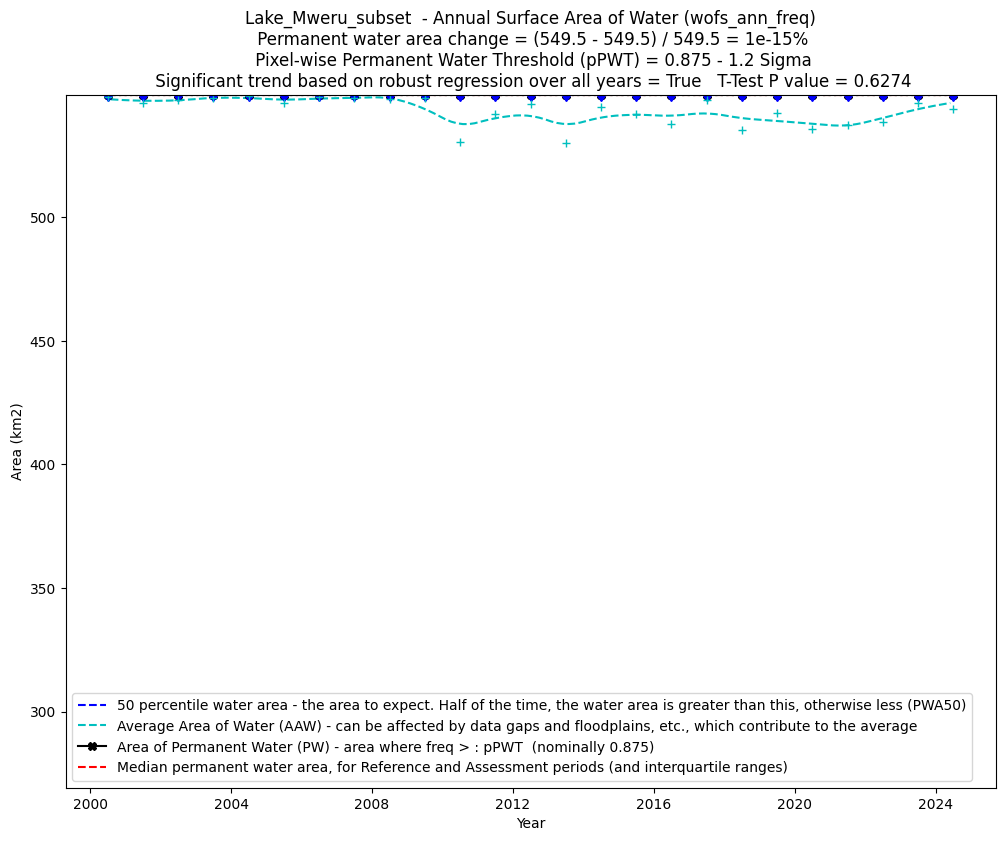

(<xarray.Dataset> Size: 759MB
 Dimensions:              (time: 25, y: 316, x: 483)
 Coordinates:
   * time                 (time) datetime64[ns] 200B 2000-07-01T23:59:59.99999...
   * y                    (y) float64 3kB -1.166e+06 -1.166e+06 ... -1.147e+06
   * x                    (x) float64 4kB 2.745e+06 2.745e+06 ... 2.774e+06
     spatial_ref          int32 4B 6933
 Data variables: (12/40)
     oli02_agm            (time, y, x) float64 31MB nan nan nan ... 136.0 134.0
     oli03_agm            (time, y, x) float64 31MB nan nan nan ... 319.0 314.0
     oli04_agm            (time, y, x) float64 31MB nan nan nan ... 166.0 166.0
     oli05_agm            (time, y, x) float64 31MB nan nan nan ... 54.0 52.0
     oli06_agm            (time, y, x) float64 31MB nan nan nan ... 73.0 65.0
     oli07_agm            (time, y, x) float64 31MB nan nan nan ... 74.0 64.0
     ...                   ...
     wofs_ann_freq_sigma  (time, y, x) float64 31MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
     wofs_ann_co

In [59]:
part2_wofs(ds,summary,water_frequency_threshold_high,'wofs_ann_freq',verbose=True,test=test)  #this does not really belong, but good to have it 
            

In [12]:
def part1a_initiate_summary(ds,verbose,test=False) :
    if verbose or test : print ("\n initiating a summary table...")
    summary = ds.drop_dims(['x','y'])     #create an annual summary by dropping the spatial dimensions
    #grab the mean number of geomedian obs for each year for each sensor and add...
    summary = summary.assign(geomedian_obs_count = 0)
    if instruments_to_use['msi_agm']['use'] :
      
        summary['geomedian_obs_count'] = summary.geomedian_obs_count +\
        xr.where(ds.msi_agm_count.mean(dim=('x','y')).notnull(),ds.msi_agm_count.mean(dim=('x','y')),0)
    if instruments_to_use['oli_agm']['use'] :
        summary['geomedian_obs_count'] = summary.geomedian_obs_count +\
        xr.where(ds.oli_agm_count.mean(dim=('x','y')).notnull(),ds.oli_agm_count.mean(dim=('x','y')),0)
    if instruments_to_use['tm_agm']['use'] :
        summary['geomedian_obs_count'] = summary.geomedian_obs_count +\
        xr.where(ds.tm_agm_count.mean(dim=('x','y')).notnull(),ds.tm_agm_count.mean(dim=('x','y')),0)
    return(summary)

In [13]:
#manual code 
summary        = part1a_initiate_summary(ds,verbose=verbose)
ds['placename'] = (),placename
summary['placename'] = (),placename

In [14]:
def part1b_gapfill_wofs(ds,verbose,test,freq_low_threshold = 0.8):
    verbose = verbose or test
    #--- this function is generally only applicable when looking at a single water area
    #--- or limited geographic extent where the areas of water vary in the same way.
    #--- therefore can't generally expect to have 'wofs_fill' as a variable elsewhere in the analysis 
    
    if verbose: print('Gap-filling wofs...')
    #--- wofs_all_freq is not ideal if the waterbody is a recently built dam. ---
    delta_t = 5   #the most recent, or closest, ref_span-year interval 
                   #will be used to get background stats on water frequency
    #ref    = np.asarray(ds.wofs_all_freq)

    ds['wofs_fill_freq'] = ('time','y','x'),(np.zeros(ds.wofs_ann_freq.size)*np.nan).reshape(ds.time.size,ds.y.size,ds.x.size)
    ds['wofs_sigma']     = ((ds.wofs_ann_freq * (1 - ds.wofs_ann_freq))/ds.wofs_ann_clearcount)**0.5

    for i in np.arange(0,ds.time.size):
        i_start = np.max([0,i-delta_t])
        i_end   = np.min([i_start+delta_t,ds.time.size])
        ref_wetcount   = ds.wofs_ann_wetcount  [i_start:i_end+1,:,:].sum(dim='time')
        ref_clearcount = ds.wofs_ann_clearcount[i_start:i_end+1,:,:].sum(dim='time')
        ref_freq       = np.array(ref_wetcount, dtype='float32')/(ref_clearcount+0.000001)

        target    = np.asarray(ds.wofs_ann_freq.isel(time=i))
        sigma     = np.asarray(ds.wofs_sigma.isel(time=i))      
        ref_freq  = np.asarray(ref_freq)      

        ds['wofs_fill_freq'].loc[ds.time[i],:,:] = wofs_gapfill(target,ref_freq,sigma,True,True,freq_low_threshold)

    
    '''    
    for year in ds.time :
        target = np.asarray(ds.wofs_ann_freq.sel(time=year))
        sigma  = np.asarray(ds.wofs_sigma.sel(time=year))
        ds['wofs_fill_freq'].loc[year,:,:] = wofs_gapfill(target,ref,sigma,True,True,freq_low_threshold)
    '''
    if verbose: plot_wofs_gapfill(ds)
    return(ds)
    

In [15]:
#manual code execution
ds             = part1b_gapfill_wofs(ds,verbose,test,0.75)
            

In [16]:
def part2_wofs(ds,summary,water_frequency_threshold,wofs_varname,verbose=False,test=False) :    
    
    ### Calculate WOfS summary statistics
    if verbose: print("Analysing WOfS for ",placename," ...")
    WFT = water_frequency_threshold
    PWT = permanent_water_threshold = 0.875
    SC  = sigma_coefficient         = 1.2
    fn  = resultsfilename = 'water_area_results.txt'
    summary,ds = wofs_summary(summary,ds,WFT,wofs_varname,PWT=0.875,SC=SC,rfname=fn,verbose=verbose,test=test)

    #--- run with different parameters to save the results
    
    #dummy,dummy1 = wofs_summary(summary,ds,WFT,'wofs_ann_freq',PWT=0.875,SC=1.2  ,rfname=fn,verbose=False,test=False)
    #dummy,dummy1 = wofs_summary(summary,ds,WFT,'wofs_ann_freq',PWT=0.875,SC=0    ,rfname=fn,verbose=False,test=False)
    #dummy,dummy1 = wofs_summary(summary,ds,WFT,'wofs_fill_freq',PWT=0.875,SC=0   ,rfname=fn,verbose=False,test=False)
    #dummy,dummy1 = wofs_summary(summary,ds,WFT,'wofs_fill_freq',PWT=0.875,SC=1.2 ,rfname=fn,verbose=False,test=False)
    gc.collect()

    #reduce all non-water areas to nd
#    ds = ds.where(ds['watermask']>0)
    return ds,summary

    

Analysing WOfS for  Lake_Mweru_subset  ...
Calculating WOfS summary...


/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:236: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/opt/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Saving results to :  water_area_results.txt


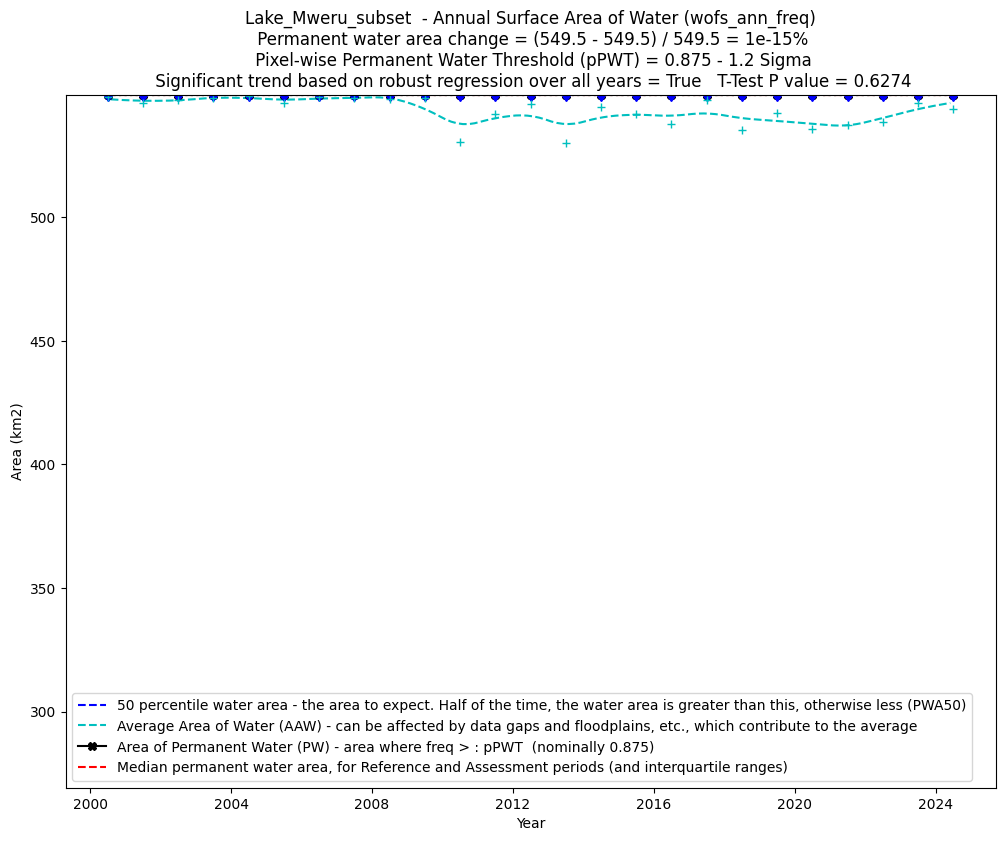

In [17]:
#manually running the function:
ds,summary     = part2_wofs(ds,summary,water_frequency_threshold_high,'wofs_ann_freq',verbose=True,test=test)  #this does not really belong, but good to have it 

In [18]:
def part3_corrections(ds,instruments,water_frequency_threshold_low,verbose=True,test=True):
    verbose = verbose or test
    if verbose: print ("Rayleigh / dark pixel correction for",placename," ...")
    dp_adjust = { 
        'msi_agm': {'ref_var':'msi12_agm','var_list': ['msi04_agm','msi03_agm','msi02_agm','msi05_agm','msi06_agm', 'msi07_agm']},
        'oli_agm': {'ref_var':'oli07_agm','var_list': ['oli04_agm','oli03_agm','oli02_agm']},
        'tm_agm' : {'ref_var':'tm07_agm', 'var_list': ['tm04_agm','tm03_agm','tm02_agm','tm01_agm']}
        }

    ds = R_correction(ds,dp_adjust,instruments,water_frequency_threshold,verbose,test)
    return ds

In [19]:
#manual execution:
ds             = part3_corrections(ds,instruments,water_frequency_threshold_high,verbose,test)
                

In [20]:
def part4_msiolicorrelation(ds,water_frequency_threshold,verbose=True,test=False):
    verbose  = verbose or test
    if not ('oli_agm' in instruments.keys() or 'msi_agm' in instruments.keys()):
        print("skipping oli/msi regression as one or more of these instruments is not in the dataset")
        return(ds)
    if verbose or test : print ("OLI/MSI regression for",placename," ...")
    oli_msi_params = msi_oli_regression(ds,water_frequency_threshold,verbose, test)

    if verbose:
        for name in oli_msi_params.keys():
            details = oli_msi_params[name]
            print(details['msi_band'],' predicting oli from MSI:',details['params'],'  msi from oli:',details['r_params'])
    if verbose or test : print (" ... done")
    return oli_msi_params
    

In [21]:
#manualexecution
oli_msi_params = part4_msiolicorrelation(ds,water_frequency_threshold_high,verbose,False)     #increases memory due to the additional variables
                

In [22]:
def part5_huevaluecalculation(ds,summary,water_frequency_threshold,verbose=False,test=False):
    if verbose or test : print ("Hue value calculations for",placename," ...")

    if not ('msi_agm' in instruments.keys()):
        print("skipping hue calculation as the msi_agm instrument is not in the dataset")
        return(ds,summary)
    ds['hue'],summary['hue'] = hue_calculation(ds,instrument='msi_agm',test=test,verbose=verbose)
    return ds,summary

In [23]:
# manual execution:
ds,summary     = part5_huevaluecalculation(ds,summary,water_frequency_threshold_high,verbose)
                

In [24]:
def part6_opticalwatertype(ds,summary,verbose=False, test = False):
    if verbose or test : print ("Optical water type estimation for",placename," ...")
    if not ('oli_agm' in instruments.keys() or 'msi_agm' in instruments.keys()):
        print("skipping OWT as relevant instruments are not in the dataset")
        return(ds,summary)
    
    #analyse the reflectances to estimate the optical water type:
    if 'msi_agm'  in instruments.keys(): ds['owt_msi_agm'],summary['owt_msi_agm_med'] = \
        OWT(ds.where(ds.wofs_fill_freq >= water_frequency_threshold),instrument='msi_agm')
    if 'oli_agm'  in instruments.keys(): ds['owt_oli_agm'],summary['owt_oli_agm_med'] = \
        OWT(ds.where(ds.wofs_fill_freq >= water_frequency_threshold),instrument='oli_agm')

    summary['owt_oli_agm'] = ds.owt_oli_agm.median(dim=('x','y'))  #an alternate way to summarise
    summary['owt_msi_agm'] = ds.owt_msi_agm.median(dim=('x','y'))

    if test or verbose: 
        print("Optical water types detected (by year)", 
              " \n MSI: \n",summary['owt_msi_agm_med'].values,
                       "\n",summary['owt_msi_agm'    ].values,
              " \n OLI: \n",summary['owt_oli_agm_med'].values,
                       "\n",summary['owt_oli_agm'    ].values)
        (ds['owt_oli_agm']).loc[ds.time[ds.time.size-6:ds.time.size]].plot(col='time',vmin=1,vmax=13,cmap='tab10')
    if verbose or test : print (" ... done")
    return ds,summary

Optical water type estimation for Lake_Mweru_subset  ...
Determining the Optical Water Type ...
Determining the Optical Water Type ...
Optical water types detected (by year)  
 MSI: 
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan  7.
  8.  8.  7.  8.  7.  8.  8.] 
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan  7.
  8.  8.  7.  8.  7.  8.  7.]  
 OLI: 
 [nan nan nan nan nan nan nan nan nan nan nan nan nan 12.  7.  6.  7.  7.
  2.  7.  7.  7.  7.  1.  1.] 
 [nan nan nan nan nan nan nan nan nan nan nan nan nan 12.  2.  6.  7.  7.
  1.  7.  7.  7.  1.  1.  1.]
 ... done


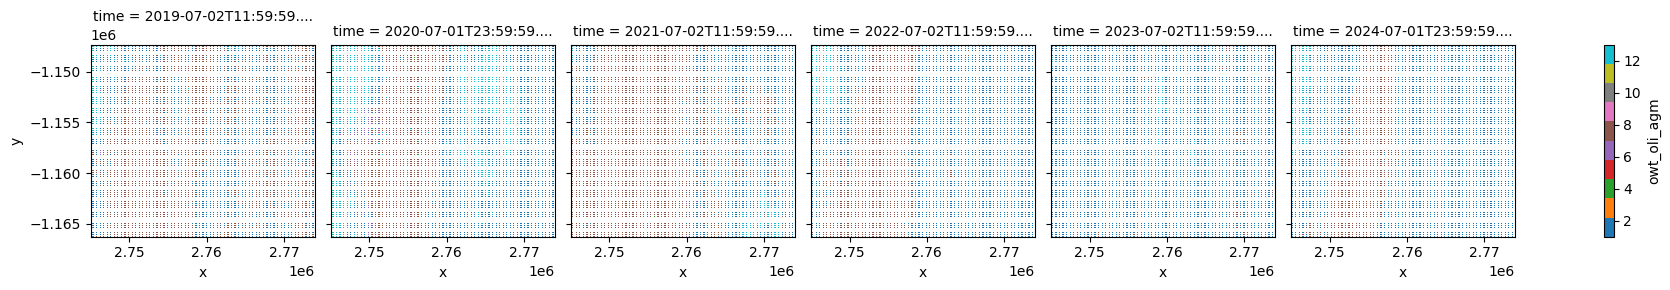

In [25]:
# manual execution:
ds,summary     = part6_opticalwatertype(ds,summary,water_frequency_threshold_high)          #this complex processing consumes twice the dataset memory to execute. 


In [26]:
def part7_waterqualitymeasures (ds,verbose = False, test=False):
    if verbose or test : print ("Chla and TSS water quality measures for ",placename," ...")
    #Set up water quality measures
    #set up which sensors and bands to use with each algorithm.
    #Each algorithm may be suitable for one or more sensors, and in special cases more than one combination of bands from a sensor
    #Not all sensors, or bands, will be available depending on the datasets loaded and the year. 
    ndci_nir_r   =  { 
                "msi_agm"   : {'54' : {'func': NDCI_NIR_R, "wq_varname" : 'ndci_msi54_agm'       ,'args' : {"NIR_band" : 'msi05_agmr', "red_band":'msi04_agmr'}},
                               '64' : {'func': NDCI_NIR_R, "wq_varname" : 'ndci_msi64_agm'       ,'args' : {"NIR_band" : 'msi06_agmr', "red_band":'msi04_agmr'}},
                               '74' : {'func': NDCI_NIR_R, "wq_varname" : 'ndci_msi74_agm'       ,'args' : {"NIR_band" : 'msi07_agmr', "red_band":'msi04_agmr'}}},
                "tm_agm"    : {'func': NDCI_NIR_R, "wq_varname" : 'ndci_tm43_agm'                ,'args' : {"NIR_band" : 'tm04_agm'  , "red_band":'tm03_agmr'}},
                "oli_agm"   : {'func': NDCI_NIR_R, "wq_varname" : 'ndci_oli54_agm'               ,'args' : {"NIR_band" : 'oli05_agm' , "red_band":'oli04_agmr'}}
                }

    chla_meris2b = {"msi_agm" : {'func': ChlA_MERIS2B, "wq_varname" : 'chla_meris2b_msi_agm' ,'args' : {"band_708" : 'msi05_agmr', "band_665":'msi04_agmr'}},
                    "msi"     : {'func': ChlA_MERIS2B, "wq_varname" : 'chla_meris2b_msi'     ,'args' : {"band_708" : 'msi05'     , "band_665":'msi04'}}}

    chla_modis2b = {"msi_agm" : {'func': ChlA_MODIS2B, "wq_varname" : 'chla_modis2b_msi_agm' ,'args' : {"band_748" : 'msi06_agmr', "band_667":'msi04_agmr'}},
                    "msi"     : {'func': ChlA_MODIS2B, "wq_varname" : 'chla_modis2b_msi'     ,'args' : {"band_748" : 'msi06'     , "band_667":'msi04'}},
                    "tm_agm"  : {'func': ChlA_MODIS2B, "wq_varname" : 'chla_modis2b_tm_agm'  ,'args' : {"band_748" : 'tm04_agmr' , "band_667":'tm03_agmr'}}}

    ndssi_rg     = {"msi_agm" : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_msi_agm'       ,'args' : { "red_band":'msi04_agmr', "green_band":'msi03_agmr'}},
                "msi"     : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_msi'           ,'args' : { "red_band":'msi04r'    , "green_band":'msi03_agmr'}},
                "oli_agm" : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_oli_agm'       ,'args' : { "red_band":'oli04_agmr', "green_band":'oli03_agmr'}},
                "oli"     : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_oli'           ,'args' : { "red_band":'oli04r'    , "green_band":'oli03r'    }},
                "tm_agm"  : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_tm_agm'        ,'args' : { "red_band":'tm03_agmr' , "green_band":'tm02_agmr' }},
                "tm"      : {'func': NDSSI_RG,     "wq_varname" : 'ndssi_rg_tm'            ,'args' : { "red_band":'tm03r'     , "green_band":'tmi02r'    }}}

    ndssi_bnir   = {#"msi_agm" : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_msi_agm'     ,'args' : { "NIR_band":'msi08_agmr', "blue_band":'msi02_agmr'}},
                "msi"     : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_msi'         ,'args' : { "NIR_band":'msi08'     , "blue_band":'msi02_agmr'}},
                "oli_agm" : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_oli_agm'     ,'args' : { "NIR_band":'oli06_agm' , "blue_band":'oli02_agmr'}},
                "oli"     : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_oli'         ,'args' : { "NIR_band":'oli06'     , "blue_band":'oli02r'    }},
                #"tm_agm"  : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_tm_agm'      ,'args' : { "NIR_band":'tm04_agm'  , "blue_band":'tm01_agmr' }},
                "tm"      : {'func': NDSSI_BNIR,   "wq_varname" : 'ndssi_bnir_tm'          ,'args' : { "NIR_band":'tm04'     , "blue_band":'tm01r'    }}}


    ti_yu        = {#"msi_agm" : {'func': TI_yu,        "wq_varname" : 'ti_yu_msi_agm'        ,'args' : {"NIR" : 'msi08_agmr', "Red":'msi04_agmr', "Green":'msi03_agmr'}},
                    "msi"     : {'func': TI_yu,        "wq_varname" : 'ti_yu_msi'            ,'args' : {"NIR" : 'msi08'     , "Red":'msi04r'    , "Green":'msi03_agmr'}},
                    "oli_agm" : {'func': TI_yu,        "wq_varname" : 'ti_yu_oli_agm'        ,'args' : {"NIR" : 'oli06_agm' , "Red":'oli04_agmr', "Green":'oli03_agmr'}},
                    "oli"     : {'func': TI_yu,        "wq_varname" : 'ti_yu_oli'            ,'args' : {"NIR" : 'oli06'     , "Red":'oli04r'    , "Green":'oli03r'    }},
                    "tm_agm"  : {'func': TI_yu,        "wq_varname" : 'ti_yu_tm_agm'         ,'args' : {"NIR" : 'tm04_agm'  , "Red":'tm03_agmr' , "Green":'tm02_agmr' }},
                    "tm"      : {'func': TI_yu,        "wq_varname" : 'ti_yu_tm'             ,'args' : {"NIR" : 'tm04'      , "Red":'tm03r'     , "Green":'tmi02r'    }}}

    tsm_lym      = {"oli_agm" : {'func': TSM_LYM_OLI,  "wq_varname" : 'tsm_lym_oli_agm'        ,'args' : {"red_band":'oli04_agmr', "green_band":'oli03_agmr'}},
                    "oli"     : {'func': TSM_LYM_OLI,  "wq_varname" : 'tsm_lym_oli'            ,'args' : {"red_band":'oli04r'    , "green_band":'oli03r'    }},
                    "msi_agm" : {'func': TSM_LYM_OLI,  "wq_varname" : 'tsm_lym_msi_agm'        ,'args' : {"red_band":'msi04_agmr', "green_band":'msi03_agmr' }},
                    "msi"     : {'func': TSM_LYM_OLI,  "wq_varname" : 'tsm_lym_msi'            ,'args' : {"red_band":'msi04r'    , "green_band":'msi03r'    }},
                    "tm_agm"  : {'func': TSM_LYM_ETM,  "wq_varname" : 'tsm_lym_tm_agm'         ,'args' : {"red_band":'tm03_agmr' , "green_band":'tm02_agmr' }},
                    "tm"      : {'func': TSM_LYM_ETM,  "wq_varname" : 'tsm_lym_tm'             ,'args' : {"red_band":'tm03r'     , "green_band":'tm02r'     }}}

    spm_qiu      = {"oli_agm" : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_oli_agm'        ,'args' : {"red_band":'oli04_agmr', "green_band":'oli03_agmr'}},
                    "oli"     : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_oli'            ,'args' : {"red_band":'oli04r'    , "green_band":'oli03r'    }},
                    "tm_agm"  : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_tm_agm'         ,'args' : {"red_band":'tm03_agmr' , "green_band":'tm02_agmr' }},
                    "tm"      : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_tm'             ,'args' : {"red_band":'tm03r'     , "green_band":'tm02r'     }},
                    "msi_agm" : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_msi_agm'        ,'args' : {"red_band":'msi04_agmr', "green_band":'msi03_agmr'}},
                    "msi"     : {'func': SPM_QIU,  "wq_varname" : 'spm_qiu_msi'            ,'args' : {"red_band":'msi04r'    , "green_band":'msi03r'    }}}

    tss_zhang        = {"msi_agm" : {'func': TSS_Zhang, "wq_varname" : 'tss_zhang_msi_agm' ,'args' : {"blue_band" : 'msi02_agmr', "red_band":'msi04_agmr', "green_band":'msi03_agmr'}},
                        "msi"     : {'func': TSS_Zhang, "wq_varname" : 'tss_zhang_msi'     ,'args' : {"blue_band" : 'msi02r'    , "red_band":'msi04r'    , "green_band":'msi03_agmr'}},
                        "oli_agm" : {'func': TSS_Zhang, "wq_varname" : 'tss_zhang_oli_agm' ,'args' : {"blue_band" : 'oli02_agmr', "red_band":'oli04_agmr', "green_band":'oli03_agmr'}},
                        "oli"     : {'func': TSS_Zhang, "wq_varname" : 'tss_zhang_oli'     ,'args' : {"blue_band" : 'oli02r'    , "red_band":'oli04r'    , "green_band":'oli03r'    }}}


    algorithms_chla = {"ndci_nir_r"   : ndci_nir_r, 
                       "chla_meris2b" : chla_meris2b, 
                       "chla_modis2b" : chla_modis2b}
    algorithms_tsm  = {"ndssi_rg"     : ndssi_rg  , 
                       "ndssi_bnir"   : ndssi_bnir, 
                       "ti_yu"        : ti_yu     ,
                       "tsm_lym"      : tsm_lym   ,
                       "tss_zhang"    : tss_zhang ,
                       "spm_qiu"      : spm_qiu    }
         

    def WQ_vars(ds,
                algorithms,
                new_dimension_name,
                new_varname,test=True):
        #Run the TSS/TSP algorithms applying each algorithm to the instruments and band combinations set in the dictionary,
        #checking that the necessary instruments are in the dataset
        if test: print(' \nRunning  WQ algorithms for:\n',list(algorithms.keys()))    
        wq_varlist =  []

        #algorithms = algorithms_tsm
        for alg in algorithms.keys():
            if test: print("\n algorithms = ",alg)
            for inst in list(algorithms[alg].keys()): 
                if test : print('instrument = ',inst)
                params = algorithms[alg][inst]
                
                if inst in list(instruments.keys()): 
                    if test : print('instrument found',inst)
                    if inst == 'msi_agm' and alg == 'ndci_nir_r' :  #special case here as options are possible
                        for option in params.keys():
                            opparams = params[option]
                            function = opparams['func']
                            ds[opparams['wq_varname']] = function(ds,**opparams['args'])
                            wq_varlist = np.append(wq_varlist,opparams['wq_varname'])
                    else: 
                        if test : print('instrument = ',inst,' new varname = ',params['wq_varname'])
                        function = params['func']
                        ds[params['wq_varname']] = function(ds,**params['args'])
                        wq_varlist = np.append(wq_varlist,params['wq_varname'])
    
        #Create a dimension for the data variables and move them into it
        new_dim_labels = list(wq_varlist)
        if test : 
            print('\nnew dimension labels (variables):\n',new_dim_labels,'\nnew dimension name: ',new_dimension_name)
  
        ds=ds.assign_coords({new_dimension_name:new_dim_labels})
        ds[new_varname] = (('time','y','x',new_dimension_name),\
        np.zeros((ds.time.size,ds.y.size,ds.x.size,ds[new_dimension_name].size)))
        if test : print("\n",ds[new_varname])
        if test : print("\n--->  ",ds[new_dimension_name].values,"  <---- new dimension values\n")
        if test : print("\n--->  ",new_varname,"  <---- new variable name (should be tss or chla\n")
        #move the tss data into the new dimension:
        for name in list(ds[new_dimension_name].values):
           if test: 
              print("\nnew_dimension_name -->",new_dimension_name)
              print("\nname               -->",name)
              print("\nnew_varname        -->",new_varname)
           ds[new_varname].loc[:,:,:,name] = ds[name]
        
        #drop  the old variables to keep it tidy:
        if True: ds= ds.drop_vars(list(ds[new_dimension_name].values))
        return ds

    #run the  functions above calculate the (non-standardised) tss and chla levels
    verbose = False
    
    ds = WQ_vars(ds.where(ds.wofs_fill_freq >= water_frequency_threshold),algorithms_tsm, 'tss_measure','tss',test)
    ds = WQ_vars(ds.where(ds.wofs_fill_freq >= water_frequency_threshold),algorithms_chla,'chla_measure','chla',test)
    if verbose or test : print (" ... done")
    return(ds)

In [27]:
# manual execution:
gc.collect()
ds             = part7_waterqualitymeasures(ds,water_frequency_threshold_high)
gc.collect()


Chla and TSS water quality measures for  Lake_Mweru_subset  ...


0

In [30]:
# the summary values for every measure, for every place, is retained in a dataset called wq_summarystats:

def part8_summarisewqresults(ds,placename,test=False,verbose=False):
    if verbose: ds.isel(time=ds.time.size-5).tss.median(dim='tss_measure').plot(robust =True)
    if verbose or test : print ("Summarising water quality measures for",placename," ...")
    
    #Save the results to an overall results dataset 
    
    #initialise a dataset for the wq results for this place. Later, we add this to the other places but not in thisfunction
    wq_summarystats = xr.Dataset(
        {
            "dummy": (["place", "tss","chla"], np.reshape(99,(1,1,1))),
        },
        coords={
            "place": [placename],
            "tss"  : ['tss'],
            "chla" : ['chla'],
            },   ) 
    
    #placenames = [placename]
    #tsss   = ['tss']
    #chlas  = ['chla']
    #wq_summarystats = xr.Dataset(
    #    {
    #        "dummy": (["place", "tss","chla"], np.reshape(99,(1,1,1))),
    #    },
    #    coords={
    #        "place": placenames,
    #        "tss"  : tsss,
    #        "chla" : chlas
    #        },    
    #
    #    )
    wq_summarystats = wq_summarystats.drop_vars('dummy')
    
    # Now, summarise the wq stats into the empty dataset
    # in the summary, the variables are the statistical summaries of the tss and chla measures - the low, median, mean and high values observed for each place
    # Eg., the median of 'ndci_msi54_agm" is called 'ndci_msi54_agm_med'
    
    tss_measures  = ds.tss_measure
    chla_measures = ds.chla_measure
    
    #aim to set these so that runaway (often high) values are excluded, but other variation is captured. 
    low_quantile  = 0.02     #this defines what the 'low' value is
    high_quantile = 0.95     #this defines what the 'high' value is. There are no dependencies on this

    wqmmt_types = (['tss',list(tss_measures.values)],['chla',list(chla_measures.values)])  # lists of all the measurements, by type (tss, chla, add others...) 
    for wqm_type in wqmmt_types :
        wqmt = wqm_type[0]                  
        for wqm in wqm_type[1]:              
            #calculate the all-time statistics for each measure
            wq_summarystats[wqm+'_low'] = \
                ('place',wqmt),ds[wqmt].loc[:,:,:,wqm].quantile(low_quantile).values.round(3).reshape(1,1)
            wq_summarystats[wqm+'_med'] = \
                ('place',wqmt),ds[wqmt].loc[:,:,:,wqm].median().values.round(3).reshape(1,1)
            wq_summarystats[wqm+'_mean'] = \
                ('place',wqmt),ds[wqmt].loc[:,:,:,wqm].mean().values.round(3).reshape(1,1)
            wq_summarystats[wqm+'_high'] = \
                ('place',wqmt),ds[wqmt].loc[:,:,:,wqm].quantile(high_quantile).values.round(3).reshape(1,1)
            
    
    if verbose or test : print (" ... done")
    return wq_summarystats  #return the summary of the wq statistics for this place.... high, med and low values for all time

In [31]:
# manual execution:
wq_stats       = part8_summarisewqresults(ds,placename)


In [32]:
# Write the summary statistics to a file for safe keeping!

def part9_savewqstats(wq_summarystats,wq_stats_filename,initialise_results_file=False,verbose = True, test = False):
    verbose = verbose or test
    #--- this function simply reads the existing results dataset in, and adds the new data, from the current place, to that results file.
    #--- if initialse_results_file is true, then the old file is deleted and we start from scratch...
    if verbose : print ("Saving TSS and Chla results for",placename," ...")
    
    #start a new results file - optional
    if initialise_results_file:
        wq_summarystats.to_netcdf(wq_stats_filename)

    #use the existing results file
    wq_allstats = xr.open_dataset(wq_stats_filename).load()
    wq_allstats.close()

    newdataset = wq_summarystats.combine_first(wq_allstats)   #this combines the old and new data, updating the old with the new values for the current place. 
    
    #and save the table
    if test:
        print('\nSaving results to ',wq_stats_filename,'...')
    newdataset.to_netcdf(wq_stats_filename)
    if verbose  : print (" ... done")
    if test     : print (wq_allstats.place)

    #repeat with a text file 
    return(newdataset)

In [33]:
# manual execution
wq_allstats    = part9_savewqstats(wq_stats,wq_stats_filename,initialise_results_file=_init,verbose=verbose,test = False)  #this retains the raw results
                

In [ ]:
%run calc_norm_parameters.ipynb   #I have externalised this function for further development. old code below

In [34]:
#def part9a_normalise_wq_stats(wq_allstats,filename,verbose=False,test=False):
if False:
    #--- this function determines the scale an offset needed to re-scale like measures 
    #--- two 'natural' assumptions are involved:
    #----- 1) that there is a natural zero, and 
    #----- 2) that median values of all measures will, over a large number of samples, converge 
    # the target variable is taken to be the median for convergence, but where there is an observed continental median available, it makes 
    # more sense to use that - e.g., for chla., 24 mg/l approx. 

    #choose target variable for normalisation - the variable that seems most realistic / stable / etc. 
    tss_target  = 'tsm_lym_oli_agm'        #this has overall q10 = 16ppt, median =  36 ppt, q90 =  59 ppt
                                           #over all measures q10 = 32, median = 44, q90 = 53. 
    chla_target = 'chla_meris2b_msi_agm'   #this seems less sensitive than the MODIS two-band model
    chla_target = 'chla_modis2b_msi_agm'   
    continental_average = True             #this seems to be a better overall approach than choosing one model as best
    if continental_average : chla_target_median = 24.5; chla_target_low = 0.0  #continental median value
    
    Q_tss  = 0.1     #the quantile to use when matching low values; this is an important parameter. Choose to match zero of the target variable.
    Q_chla = 0.1
    #initialise a dataset to hold the normalisation parameters
    np_data = wq_allstats.drop_dims(('place'))

    if test or verbose : print('Calculating scale and offset for data normalisation..')
    #--- run through all the wq measures 
    for varname in list(wq_allstats.data_vars):
        if varname.endswith('_med') : 
            varname_base =  varname[:varname.find('_med')]
            if 'tss'  in wq_allstats[varname].dims : 
                targetvar = tss_target;  Q = Q_tss
                scale       = np.round((wq_allstats[   targetvar+'_med'].median(dim=('place')) - wq_allstats[   targetvar+'_low'].quantile(Q,dim=('place'))) /\
                                       (wq_allstats[varname_base+'_med'].median(dim=('place')) - wq_allstats[varname_base+'_low'].quantile(Q,dim=('place'))),3)          
                offset      = np.round (wq_allstats[    targetvar+'_low'].quantile(Q,dim=('place')) - ( wq_allstats[varname_base+'_low'].quantile(Q,dim=('place')) * scale ),3) 
            
            if 'chla' in wq_allstats[varname].dims : 
                targetvar = chla_target; Q = Q_chla
                if continental_average:
                    scale       = np.round((chla_target_median - chla_target_low) /\
                                           (wq_allstats[varname_base+'_med'].median(dim=('place')) - wq_allstats[varname_base+'_low'].quantile(Q,dim=('place'))),3)          
                    offset      = np.round ((chla_target_low)                                      - (wq_allstats[varname_base+'_low'].quantile(Q,dim=('place')) * scale ),3) 
                else :
                    scale       = np.round((wq_allstats[   targetvar+'_med'].median(dim=('place')) - wq_allstats[   targetvar+'_low'].quantile(Q,dim=('place'))) /\
                                       (wq_allstats[varname_base+'_med'].median(dim=('place')) - wq_allstats[varname_base+'_low'].quantile(Q,dim=('place'))),3)          
                    offset      = np.round (wq_allstats[    targetvar+'_low'].quantile(Q,dim=('place')) - ( wq_allstats[varname_base+'_low'].quantile(Q,dim=('place')) * scale ),3) 
            if test or verbose : print(varname_base, scale.values, offset.values)
            np_data[varname_base+'_scale' ] = scale;
            np_data[varname_base+'_offset'] = offset;
    
    np_data.to_netcdf(filename)        

    # --- convert the normalisation parameter values to a dictionary for simpler handling ---
    np_data_dict = {}

    # --- for varname in (['ndssi_rg_msi_agm_scale','ndssi_rg_msi_agm_offset']):
    for varname in (np_data.data_vars):
        value   = np_data[varname].item(0)  
        if varname.endswith('_scale'):
            base = varname[:varname.find('_scale')]
            if not base in np_data_dict.keys():
                np_data_dict[base] = {}
            np_data_dict[base]['scale'] = value
        if varname.endswith('_offset'):
            base = varname[:varname.find('_offset')]
            if not base in np_data_dict.keys():
                np_data_dict[base] = {}
            np_data_dict[base]['offset'] = value

    # --- write the dictonary to a file in the work area for WP 1.4 --- 
    jfilename = '../dev/deafrica_water_quality/WP1.4/'+nparams_filename[:nparams_filename.find('.')]+'.json'
    with open(jfilename, 'w') as f:
      json.dump(np_data_dict, f)

    #with open(jfilename) as f:
    #  np_data_dict1 = json.load(f)

    return np_data

In [35]:
# manual execution:
np_data        = part9a_normalise_wq_stats(wq_allstats,nparams_filename,verbose = verbose, test = False) #calculate normalisation parameters for each wq statistic such that they can be used as an ensemble


In [36]:
def part9b_apply_wq_normalisation_parameters(ds,np_data,verbose=True,test=False):
    #--- apply the normalisation parameters to the dataset variables and the summary ---

    # --- read the normalisation parameters from the json file in the work area for WP 1.4 --- 
    jfilename = '../dev/deafrica_water_quality/WP1.4/'+nparams_filename[:nparams_filename.find('.')]+'.json'
    
    with open(jfilename) as f:
      np_data_dict = json.load(f)

    ds1 = ds.copy(deep=True)   #without this the ds values do change outside of the function
    s1  = summary.copy(deep=True)
    if test or verbose : print('Applying scale and offset to wq variables..')
    
    #run through all the wq measures 
    for mmt_type in ['tss','chla'] :
        for mmt in list(ds[mmt_type+'_measure']) :
            measurement = str(mmt.values)
            scale  = np_data_dict[measurement]['scale']
            offset = np_data_dict[measurement]['offset']
            ds1[mmt_type].loc[:,:,:,measurement] = ds[mmt_type].loc[:,:,:,measurement] * scale + offset
    return ds1

In [50]:
# manual execution:
ds1             = part9b_apply_wq_normalisation_parameters(ds,np_data,verbose=verbose,test=False)
ds = ds1

<xarray.DataArray 'tss_measure' (tss_measure: 14)> Size: 1kB
array(['ndssi_rg_msi_agm', 'ndssi_rg_oli_agm', 'ndssi_rg_tm_agm',
       'ndssi_bnir_oli_agm', 'ti_yu_oli_agm', 'ti_yu_tm_agm',
       'tsm_lym_oli_agm', 'tsm_lym_msi_agm', 'tsm_lym_tm_agm',
       'tss_zhang_msi_agm', 'tss_zhang_oli_agm', 'spm_qiu_oli_agm',
       'spm_qiu_tm_agm', 'spm_qiu_msi_agm'], dtype='<U18')
Coordinates:
    spatial_ref  int32 4B 6933
  * tss_measure  (tss_measure) <U18 1kB 'ndssi_rg_msi_agm' ... 'spm_qiu_msi_agm'

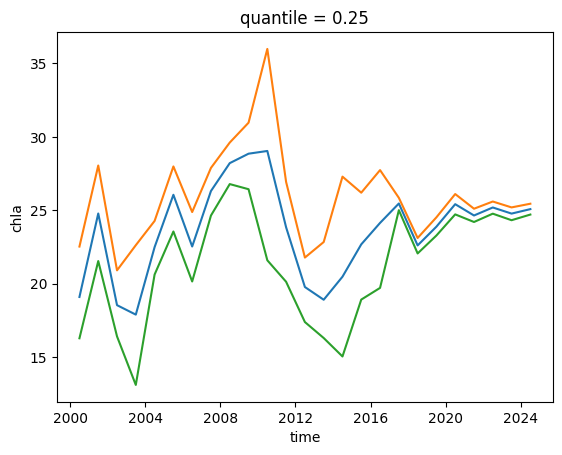

In [100]:
ds1.chla.median(dim='chla_measure').mean(dim=('x','y')).plot()
ds1.chla.median(dim='chla_measure').quantile(.75,dim=('x','y')).plot()
ds1.chla.median(dim='chla_measure').quantile(.25,dim=('x','y')).plot()
#ds1.ndci.loc['ndci_msi54_agm']
ds1.tss_measure


In [115]:
tss_index_list  = ds.tss_measure   # --- which measures to include  ----
ds['tss_agm_med' ] = ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure'))

chla_index_list = ds.chla_measure
ds['chla_agm_med'] = ds.chla.loc[:,:,:,chla_index_list].median(dim=('chla_measure'))

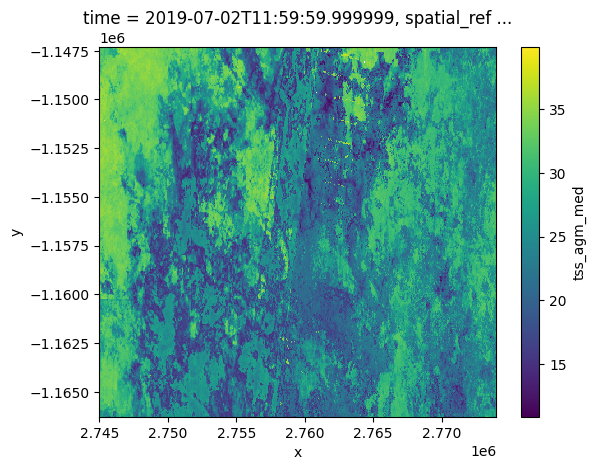

In [117]:
ds.tss_agm_med.sel(time='2019').plot()

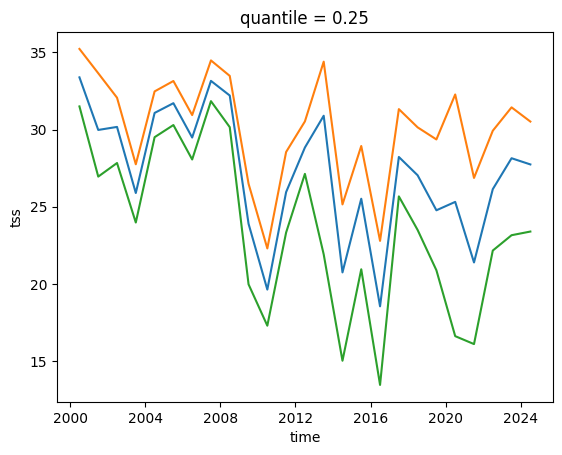

In [ ]:
# median of the mean of the chla indices :
chla_index_list = ['ndci_msi54_agm', 'ndci_msi64_agm', 'ndci_msi74_agm', 'ndci_tm43_agm','ndci_oli54_agm']
#ds.chla.loc[:,:,:,chla_index_list].mean(dim=('chla_measure')).median(dim=('x','y')).plot()

# median of the mean of the all the chla measures :
chla_index_list = ds.chla_measure
tss_index_list  = ['ndssi_rg_msi_agm', 'ndssi_rg_oli_agm', 'ndssi_rg_tm_agm','ndssi_bnir_oli_agm']

#ds.chla.loc[:,:,:,chla_index_list].mean(dim=('chla_measure')).median(dim=('x','y')).plot()

# median of the median of the chla indices : 
#ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')).median(dim=('x','y')).plot()
#ds.tss.loc[:,:,:,tss_index_list].max(dim=('tss_measure')).median(dim=('x','y')).plot()
#ds.tss.loc[:,:,:,tss_index_list].min(dim=('tss_measure')).median(dim=('x','y')).plot()

# median and ranges of the median of alll tss measures : 
tss_index_list  = ds.tss_measure
ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')).median(dim=('x','y')).plot()
ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')).quantile(.75,dim=('x','y')).plot()
ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')).quantile(.25,dim=('x','y')).plot()
#ds.tss.loc[:,:,:,tss_index_list].max(dim=('tss_measure')).median(dim=('x','y')).plot()
#ds.tss.loc[:,:,:,tss_index_list].min(dim=('tss_measure')).median(dim=('x','y')).plot()

#ds1.tss_measure

In [52]:
def part10_savesummary(summary,thisplace,summary_filename,initialise=False,verbose=True,test=True):
    if verbose or test : print ("Saving summary of results for :",thisplace," ...")
    #tss and chla data are dealt with elsewhere
    #add the place dimension to the summary dataset & expand existing variables into the place dimension:
    
    summary =summary.assign_coords({'place':[thisplace]})
    for varname in summary.data_vars:
        summary[varname] = summary[varname].expand_dims('place')

    #initiate a data file for the results
    if initialise:
        if test or verbose : print("initialising the summary file")
        all_summary = summary
        all_summary.to_netcdf(summary_filename)
        return all_summary

    #use the existing results file which will include all places processed so far
    all_summary = xr.open_dataset(summary_filename).load()
    all_summary.close()
    if test or verbose : print("writing the summary file")
    #append the new data to the existing summary, and write to file
    (summary.combine_first(all_summary)).to_netcdf(summary_filename)
    #return the new and old data as the summary
    return(summary.combine_first(all_summary))
    

In [53]:
# manual execution
all_summary    = part10_savesummary(summary,placename,summary_filename,initialise=_init,verbose=verbose,test=False) #saves the general summary data


In [54]:
def part10a_wq_summary(ds,thisplace,wq_summary_filename,initialise=False,test=False,verbose=False):
    #--- this function saves the normalised data variables to a wq summary file (initiating or appending as appropriate).
    #--- it would be better to do this as a final step for all places, working from the raw stats.
    
    if verbose or test : print ("Calculating summary values for WQ measures for ",placename," ...")
    # adding the annual results, for each wq measure, to the summary file. 
    #These values are adjusted based on the normalisation coefficients which are based on the wq_allstats data captured from many water areas over many years.  
    tss_measures  = ds.tss_measure
    chla_measures = ds.chla_measure
    low_quantile  = 0.1
    high_quantile = 0.9
    #deal with the possibility that there are no new variables for either tss or chla...
    mlist = []
    for mmt in ['tss','chla'] :  
        if ds[mmt+'_measure'].size > 0 :mlist = np.append(mlist,mmt)
    if np.size(mlist) == 0 :
        old_summary = xr.open_dataset(wq_summary_filename).load();     old_summary.close()        
        return old_summary

    #for this wq summary we want to keep all the WQ measures separate, and have their high,med and low values
    #for once, xarray makes this really simple. 
    params = {'tss_low':0.1, 'chla_low':0.1, 'tss_high':0.9, 'chla_high':0.9}
    new = {}
    for mmt in mlist :
        qlow  = 'q'+str(int(params[mmt+'_low' ]*100))    
        qhigh = 'q'+str(int(params[mmt+'_high']*100))
        new = xr.merge  (
            (new,
             ds[mmt].quantile(params[mmt+'_low' ],dim=('x','y')).to_dataset().rename_vars({mmt:mmt+'_'+qlow}).drop_vars('quantile'),
             ds[mmt].quantile(params[mmt+'_high'],dim=('x','y')).to_dataset().rename_vars({mmt:mmt+'_'+qhigh}).drop_vars('quantile'),
             ds[mmt].median  (           dim=('x','y')).to_dataset().rename_vars({mmt:mmt})))
    new = new.assign_coords({'place':[thisplace]})
    for varname in new.data_vars:
        new[varname] = new[varname].expand_dims('place')
    
    wq_summary = new
        
    #merge with other places, or create a new file
    if initialise:
        if test or verbose : print("initialising the wq measures summary file")
        wq_summary.to_netcdf(wq_summary_filename)
    else :     
        #use the existing results file which will include all places processed so far
        old_summary = xr.open_dataset(wq_summary_filename).load();     old_summary.close()        
        wq_summary  = wq_summary.combine_first(old_summary)

    #write results to file:
    if test or verbose : print("writing the summary file")
    wq_summary.to_netcdf(wq_summary_filename)
    return wq_summary


In [55]:
# manual execution
wq_summary     = part10a_wq_summary(ds,placename,wq_summary_filename,initialise=_init,verbose=verbose,test=False)


/opt/venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/opt/venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


# STOP

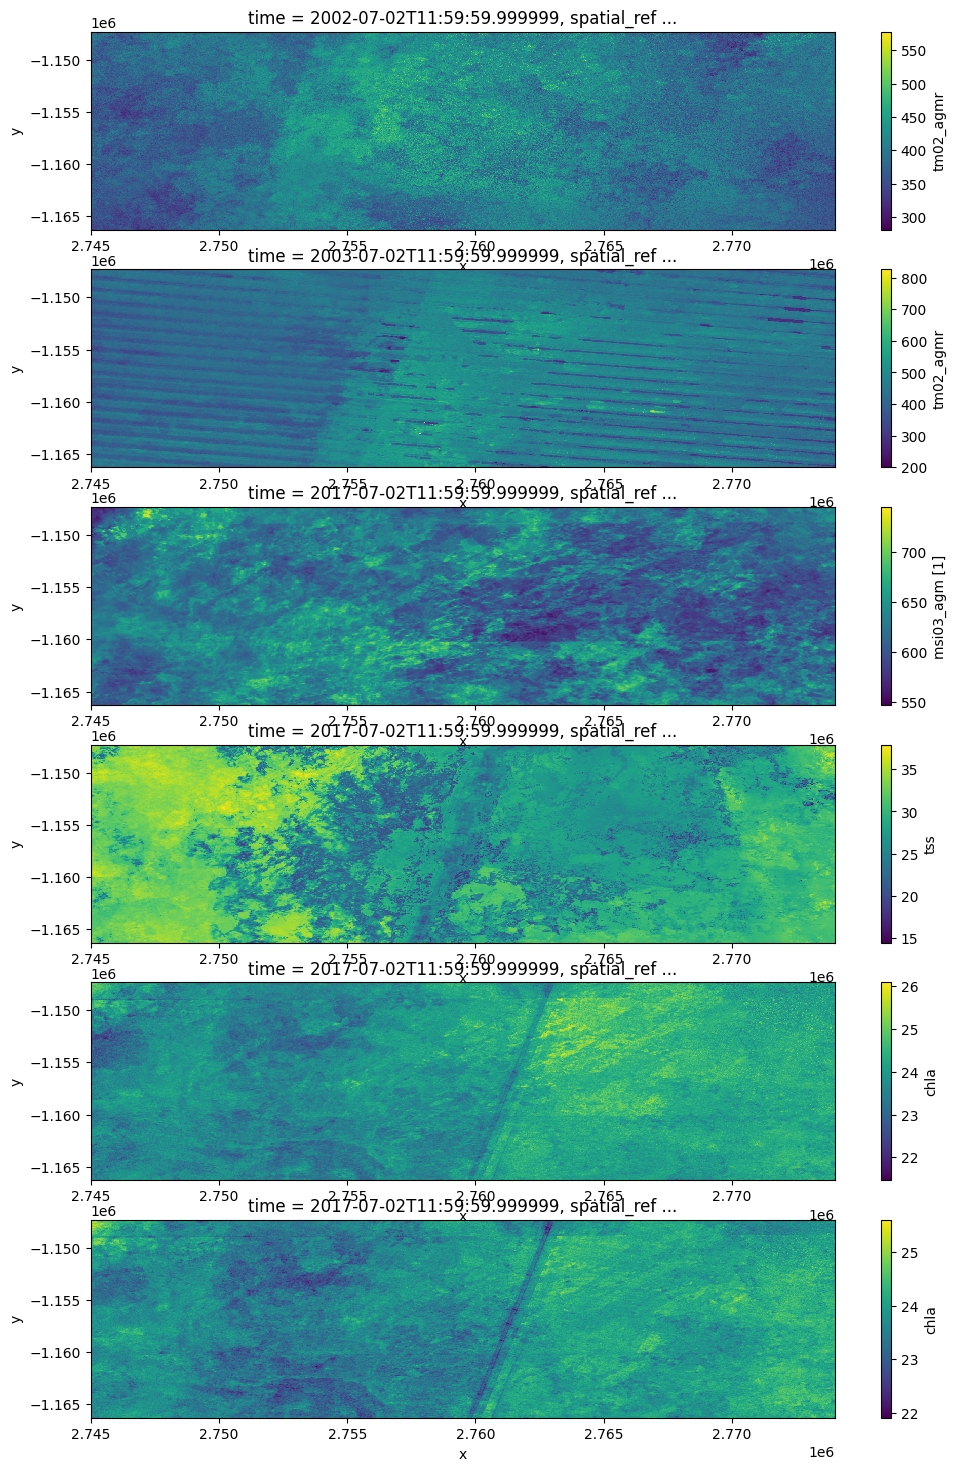

In [163]:
year1 = ds.time[2]
year2 = ds.time[3]
year3 = ds.time[17]
x0 = 0
x1 = ds.x.size-1
y0 = 0
y1 = ds.y.size-1

#ds.tm01_agm.loc[year1,([ds.x[200:210]]),:]
#ds.x[200:210]
#ds[['tm01_agm', 'tm02_agm', 'tm03_agm']].sel(time=year1)#.loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]]
#ds['tm01_agm'].sel(time=year1).loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]]
#ds['tm01_agm'].sel(time=year1).loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]]
plt.figure(figsize=(12,18))
plt.subplot(611)
ds.sel(time=year1)['tm02_agmr'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].plot()
plt.subplot(612)
ds.sel(time=year2)['tm02_agmr'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].plot()
plt.subplot(613)
ds.sel(time=year3)['msi03_agm'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].plot()
plt.subplot(614)
ds.sel(time=year3)['tss'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].median(dim='tss_measure').plot()
plt.subplot(615)
ds.sel(time=year3)['chla'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].median(dim='chla_measure').plot()
plt.subplot(616)
ds.sel(time=year3)['chla'].loc[ds.y[y0]:ds.y[y1],ds.x[x0]:ds.x[x1]].loc[:,:,'ndci_msi74_agm'].plot()



In [145]:
ds['gm_count']= ('time','y','x'), np.nanmax((ds.tm_agm_count,ds.oli_agm_count,ds.msi_agm_count),axis=0)

Calculating WOfS summary...
water area calculated as :  <xarray.DataArray 'wofs_ann_wetcount' ()> Size: 8B
array(549.84)
Coordinates:
    spatial_ref  int32 4B 6933  Total study area is  549.84


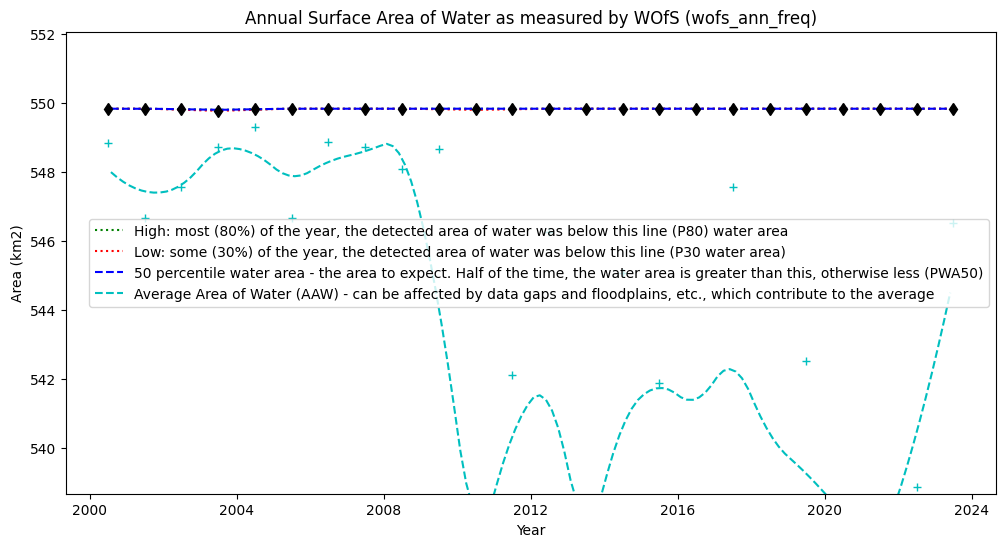

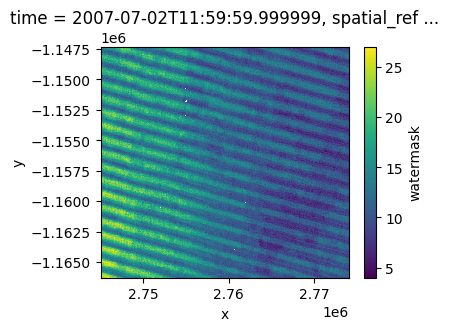

In [126]:
%run _WOfS-summary-v1.0.ipynb
dummy=wofs_summary(summary,ds,0.9,'wofs_ann_freq')

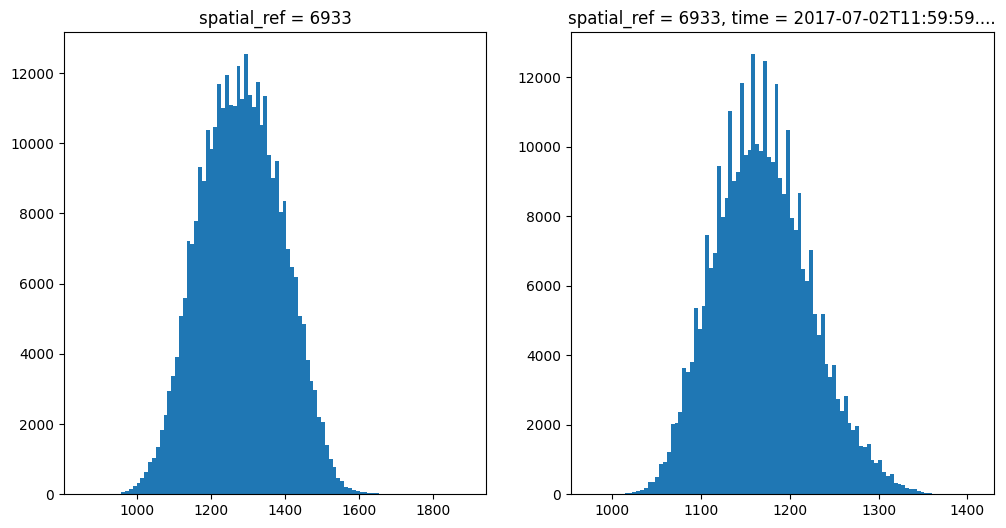

In [121]:
year1,year2 = ds.time[[2,17]]
plt.figure(figsize=(12,6))
plt.subplot(121)
(h)=(\
ds.tm01_agm.sel(time = year1)+
    ds.tm02_agm.sel(time=year1)+
    ds.tm03_agm.sel(time=year1))\
.where(ds.wofs_fill_freq.sel(time=year) >.9)\
.plot.hist(bins=100)
plt.subplot(122)
(hmin)=(\
ds.msi03_agm.min(dim='time')\
+ds.msi02_agm.min(dim='time')\
+ds.msi04_agm.min(dim='time')\
)\
.where(ds.wofs_fill_freq.sel(time=year) >.9)\
.plot.hist(bins=100)
plt.show()

#.where(ds.wofs_fill_freq.sel(time=year) >-1)\
#.plot.hist(bins=100)
#.plot.hist(bins=50)

In [ ]:
test = True
if test: 
    rgb(ds.isel(time=-4),
    bands=["msi04_agmr","msi03_agmr","msi02_agmr"], robust = True) #,col="time",robust=True)
if False :   
    rgb(msi_agm.isel(time=-4),
    bands=["msi04_agm","msi03_agm","msi02_agm"], robust = True) #,col="time",robust=True)
    #composite['msi04_agmr'] = ds['msi04_agmr'].where(ds['msi04_agmr'],msi_agm['msi04_agm'])  #this fails due to the time dimension...
    # need to know the join parameter options (join = ...)


In [ ]:
rgb(ds.isel(time=-5),bands=["msi04_agm","msi03_agm","msi02_agm"], robust = True) #,col="time",robust=True)

In [ ]:
ds.chla.isel(time=20).quantile(.5,dim=('chla_measure')).plot(robust=True)

In [ ]:
from statistics import geometric_mean
#return np.exp(np.log(iterable).mean())
ds.chla.isel(time=20).geometric_mean(dim=('chla_measure')).plot(robust=True)

In [ ]:
ds.data_vars

### Map algal blooms 
#### Step 1: convert from RGB to CIE colour units
#### Step 2: implement the floating algal index (paper needed)
#### Step 3: apply a threshold

### Otsu ...
Note for Ron, Implement Otsu's 1979 algorithm for optimal splitting of a grey-scale into bimodal / trimodal distributions. Useful tool for separating valid observations in an image time-series from invalid observations resulting from aberrations in illumination or occlusion. Iterative application possibly. Linear sequential arithmetic. Also useful for splitting waterbody into sub-areas I suspect.
- notice this has been done on GEE somewhere - refered to in a papaer on WQ / elephants 

### Standardise the ChlA outputs to what appears to be the most robust model (i.e. MERIS-2band, MSI)

In [ ]:
#Rescale the variables to match ChlA MERIS two-band model - 
#(seems to provide the most stable and reasonable values). 
#Process is to match lowest values with zero, and match the medians by scaling
#The median values and reasonable range extremes can eb adjusted over time with more data
#These values to be tuned based on a larger sample of sites. 

variable_list = [ 
                 ['ChlA_MERIS2B',"ChlA 'MERIS 2-Band model', MSI bands 5-4",  0,   102.5,    360],
                 ['ChlA_MODIS2B',"ChlA 'MODIS 2-Band model', MSI bands 6-4",  0,   213.6,    900], 
                 ['ndci_msi54','Normalised Difference ChlA, MSI bands 5-4', -0.102, 0.24025,  0.7 ],
                 ['ndci_msi64','Normalised Difference ChlA, MSI bands 6-4', -0.646, 0.01788,  0.66],
                 ['ndci_msi74','Normalised Difference ChlA, MSI bands 7-4', -0.636, 0.03075,  0.66]
                ]
if _tm:
    variable_list = variable_list +  [['ndci_etm43','Normalised Difference ChlA, ETM bands 4-3', -0.454, -0.087  ,  0.46]]


ref_min = variable_list[0][2]
#ref_max = variable_list[0][4]
ref_med = variable_list[0][3]

test = False
for variable in variable_list:
    #this is not correct, the scaling needs to be applied to the shift also.
    #shift = np.round((ref_min - variable[2]),3)
    scale = np.round((ref_med - ref_min) / (variable[3] - variable[2]),3)
    shift = np.round((ref_min - scale * (variable[2])),3)
    name = variable[0]
    
    if test :
        print(ref_min,variable[2], shift)
        print(name,
              ds[name].quantile(.05).values.round(3), 
              ds[name].median().values.round(3),
              ds[name].quantile(0.95).values.round(3))
        name = 'test'+name

    
    ds[name] = (ds[variable[0]] + shift ) * scale
    if True :
        print(name,
              ds[name].quantile(.05).values.round(3), 
              ds[name].median().values.round(3),
              ds[name].quantile(0.95).values.round(3))
    
    #medval = ds[variable[0]].sel(time=year).median().values.round(2)

    

### Save median results into the summary table

In [ ]:
for variable in variable_list:
    itemname = variable[0]
    summary[itemname] = ds[itemname].median(dim=('x','y'))
    print(summary[itemname].min().values,summary[itemname].mean().values,summary[itemname].max().values)

In [ ]:
#plot the ChlA variables
test = False
    
fig, ax = plt.subplots(3, 3, figsize=(12, 12))
#cmap='GnBu_r'
cmap='viridis'
year = '2020'


#low = 0.05; high = 1.0 - low;
row = 1; col = 1; ncols = 2; 


for variable in variable_list :
    #print("--------"); print(row,col)
    #minval = ds[variable[0]].sel(time=year).quantile(low).values.round(2)
    #maxval = ds[variable[0]].sel(time=year).quantile(high).values.round(2)
    #medval = ds[variable[0]].sel(time=year).median().values.round(2)
    plotmin = 0
    plotmax = 250
    
    if test : 
        varname = str('test')+variable[0]
        print(varname, 'test'+variable[0])
    else:
        varname = variable[0]
    print(varname)
    
    ds[varname].sel(time=year).plot(
        ax=ax[row-1, col-1], cmap=cmap, add_colorbar=True, 
        vmin=plotmin, 
        vmax=plotmax)
        

    
    ax[row-1, col-1].set_title(variable[1]),
    ax[row-1, col-1].xaxis.set_visible(False),
    ax[row-1, col-1].yaxis.set_visible(True)
    col += col;
    if col > ncols:
        col =  1; row += 1;
        
print(
    ""
    )
plt.tight_layout();

In [ ]:
if True: 
    rgb(ds.sel(time=slice('2020',year2)),
    bands=["ChlA_MERIS2B","ChlA_MODIS2B","ndci_msi74"],
    col="time",robust=True)

In [ ]:
test = True

#### Working values for the median and range of indices / measures used here. 
- Anticipate using the modes and ranges to match variables to a common scale.

| Model or index | min-median-max |
|-------------------------------------------|-----------------------------|
| ChlA 'MERIS 2-Band model', MSI bands 5-4  |  38    --  102.5     -- 357.75   
| ChlA 'MODIS 2-Band model', MSI bands 6-4  |   8.5  --  213.5     -- 886.55
| Normalised Difference ChlA, MSI bands 5-4 |  -0.10 --    0.2403  --   0.7
| Normalised Difference ChlA, MSI bands 6-4 |  -0.65 --    0.0189  --   0.66
| Normalised Difference ChlA, MSI bands 7-4 |  -0.64 --    0.0308  --   0.66
| Normalised Difference ChlA, ETM bands 4-3 |  -0.454 --   -0.087    --   0.46





In [ ]:
#now can grab median tss values from multiple sources!!
#summary['chla'].sel(chla_measure='ChlA_MERIS2B').median(dim='time').values
print(summary['chla'].min(dim='chla_measure').values,
    summary['chla'].max(dim='chla_measure').values,
    summary['chla'].median(dim='chla_measure').values,
    summary['chla'].mean(dim='chla_measure').values,
     summary['chla'].count(dim='chla_measure').values)

In [ ]:
#plot the time series of median chla measurements...
chla_measures = (summary.chla.isel(chla_measure=[0,1,2,3,4,5]))
timedim = np.size(chla_measures.time)
y_upper_graph = (summary['chla'].median()-summary['chla'].min()) * 10 
chla_measures.plot.line(hue="chla_measure", xlim=(chla_measures.time[timedim-8],chla_measures.time[timedim-1]),
                      ylim=(-0,y_upper_graph))
                      

Multiple models are demonstrated in the notebook exmaple water_quality_suspended_matter
We should use these as an ensemble.

In [ ]:
#inspect some results
if False:
    minval = ds['ti_yu_etm'].min()
    maxval = ds['ti_yu_etm'].max()
    ds["ti_yu_etm"].sel(time='2011').plot(vmin=minval, vmax=maxval)

if False:
    ds['tsm_lym_oli'].sel(time=slice(year1,year2)).plot(col='time',vmin=1,vmax=260)
    ds['tsm_lym_etm'].sel(time=slice(year1,year2)).plot(col='time',vmin=1,vmax=260)

if False:
    ds['spm_qiu_oli'].sel(time=slice(year1,year2)).plot(col='time',vmin=0,vmax=100)

if False:
    (ds['tss_zhang_msi'].sel(time=slice(year1,year2))).plot(col='time',vmin=1,vmax=100)

if False :
    ds['ti_yu_etm'].sel(time=slice(year1,year2)).plot(col='time',vmin=0,vmax=5)
    print(ds['ti_yu_oli'].max())

In [ ]:
#print off the un-standardised median and min values for use in standardisation
variable_list = [
                 ['tsm_lym_oli','Total Suspended Matter, Lymburner, OLI',                               0,  23.3,  250  ],
                 ['tsm_lym_etm','Total Suspended Matter, Lymburner, ETM',                            31.5,  64.1,  250  ],  #scaling as with oli version
                 ['spm_qiu_oli','Suspended Particulate Matter, Qiu, OLI',                               0,  32.6, 1000  ], 
                 ['tss_zhang_oli','Total Suspended Sediment, Zhang, OLI',                               1,  15.6,   50  ],
                 ['tss_zhang_msi','Total Suspended Sediment, Zhang, MSI',                               1,   2.4,   20  ],
                 ['ndssi_bNIR_oli','Normalised Difference Suspended Sediment Index (blue-NIR), OLI', -1.0,  -0.46,   1.0],
                 ['ndssi_bNIR_msi','Normalised Difference Suspended Sediment Inded (blue-NIR), MSI', -1.0,  -0.31,   0.5],
                 ['ndssi_rg_oli','Normalised Difference Suspended Sediment Index (red-green), OLI',  -1.0,  -0.07,   0.5],
                 ['ndssi_rg_msi','Normalised Difference Suspended Sediment Inded (red-green), MSI',  -0.3,  -0.04,   0.2],
                 ['ti_yu_oli','Turbidity Index, Yu (Red-green)-(NIR-green), OLI',                    -1.0,   0.01,   6.0],
                 ['ti_yu_etm','Turbidity Index, Yu (Red-green)-(NIR-green), TM',                    -3.05,  -0.345,   6.0], #default scaling following the oli version
                ]
for variable in variable_list:
    variable_name = variable[0]
    if (variable_name in ds.data_vars) :
        print(ds[variable_name].quantile(0.02).values.round(3),ds[variable_name].median().values.round(3))


### Re-scale the model outputs to be compatible with the most robust model (i.e., Lymburner TSM, OLI)

####  Method : 
- First: assume that the lowest percentile values observed, across all waterbodies, correspond to zero.
- Then: set the median value, again as observed across a range of sites, to be equal to the median of the reference model
- Finally: apply a linear transformation based on these two assumptions, which we propose to be reasonable if the index or measure is usefully capturing the property of interest.



In [ ]:
## Inspect maps of algorithms' outputs for TSS

In [ ]:

#This list includes reasonable lower, upper, and median values observed across the data. These values can be revised.
#Re-scaling process is :
# 1) apply an offset to the lower values to be zero
# 2) scale the median values to match the target distribution.

variable_list = [
                 ['tsm_lym_oli','Total Suspended Matter, Lymburner, OLI',                               0,  23.3,  250  ],
                 ['spm_qiu_oli','Suspended Particulate Matter, Qiu, OLI',                               0,  32.6, 1000  ], 
                 ['tss_zhang_oli','Total Suspended Sediment, Zhang, OLI',                               1,  15.6,   50  ],
                 ['tss_zhang_msi','Total Suspended Sediment, Zhang, MSI',                               1,   2.4,   20  ],
                 ['ndssi_bNIR_oli','Normalised Difference Suspended Sediment Index (blue-NIR), OLI', -1.0,  -0.46,   1.0],
                 ['ndssi_bNIR_msi','Normalised Difference Suspended Sediment Inded (blue-NIR), MSI', -1.0,  -0.31,   0.5],
                 ['ndssi_rg_oli','Normalised Difference Suspended Sediment Index (red-green), OLI',  -1.0,  -0.07,   0.5],
                 ['ndssi_rg_msi','Normalised Difference Suspended Sediment Inded (red-green), MSI',  -0.3,  -0.04,   0.2],
                 ['ti_yu_oli','Turbidity Index, Yu (Red-green)-(NIR-green), OLI',                    -1.0,   0.01,   6.0],
                 ]
#a better work around is to check if the variable name is in ds.data_vars
if _tm :
    variable_list = variable_list + [
                 ['tsm_lym_etm','Total Suspended Matter, Lymburner, ETM',                               0,  23.3,  250  ], #scaling with OLI version as they are very consistent  
                 ['ti_yu_etm','Turbidity Index, Yu (Red-green)-(NIR-green), TM',                   -3.05,  -0.345,   6.0]
                 ] 
                 
                 

### Save median results into the summary table

In [ ]:
#set up TSS as a dimension for these measurements ...
# list of items to become the coordinates of the new dimension...
namelist = []
for v in variable_list :
    if (v[0] in np.asarray(ds.data_vars)) :
        namelist.append(v[0])
    else:
        print(v[0],': not found in the dataset')

#make a coordinate object ...
tss_coords = xr.Coordinates(
    {
        "tss_measure": namelist
    }
)

#assign the coordinates to the summary dataset ...
summary = summary.assign_coords(tss_coords)

#create a variable that uses the dimension ..
dimensions = (np.size(summary.tss_measure),np.size(summary.time))
summary['tss'] = (('tss_measure','time'),np.zeros(dimensions))
#and set to nodata...
summary['tss'] = summary.tss.where(summary.tss > 0)

#finally and with fingers crossed, allocate some data ... 
#but can't do it with the coordinate lablel have to use the index which is inferior because I am assuming the order is unchanged
#summary['tss'][0] = ds['tsm_lym_oli'].median(dim=('x','y'))

i = 0
for variable in variable_list:
    itemname = variable[0]
    if (itemname in np.asarray(ds.data_vars)) :
        summary['tss'][i] = ds[itemname].median(dim=('x','y'))
        i = i + 1

### Plot the results

In [ ]:
test = False

fig, ax = plt.subplots(6, 2, figsize=(10,16))
cmap='viridis'
year = '2020'

plotmin = 0
plotmax = 250

low = 0.05; high = 1.0 - low;
row = 1; col = 1; ncols = 2; 

for variable in variable_list :
    name = variable[0]
    if test :
        name = 'test'+variable[0]
    if test : print(name)
    #minval = ds[variable[0]].sel(time=year).quantile(low).values.round(2)
    #maxval = ds[variable[0]].sel(time=year).quantile(high).values.round(2)
    #medval = ds[variable[0]].sel(time=year).median().values.round(2)
    #plotmin = variable[2]
    #plotmax = variable[4]
    #if plotmin == -10 :
    #    plotmin = ds[variable[0]].quantile(low).values
    #    plotmax = ds[variable[0]].quantile(high).values
          
    #print(variable[1],": ",minval,"-- ",medval," --", maxval)
 
    ds[name].sel(time=year).plot(
        ax=ax[row-1, col-1], cmap=cmap, add_colorbar=True,
        vmin=plotmin, 
        vmax=plotmax)
    ax[row-1, col-1].set_title(variable[1]), ax[row-1, col-1].xaxis.set_visible(False), ax[row-1, col-1].yaxis.set_visible(False)
    col += col;
    if col > ncols:
        col =  1; row += 1;
        
plt.tight_layout();

### Reasonable/working values for the median and range of  measures used here:

- note: the upper range is not used in standardisation

|   variable | min -- median -- max |
|--------------------------------------------------------------|------------------------------|
|- Total Suspended Matter, Lymburner, OLI :                     |      0.0 --  23.28  -- 163.79  |
|- Total Suspended Matter, Lymburner, ETM :                     |      tba --  tba  -- tba  |
|- Suspended Particulate Matter, Qiu, OLI :                      |    0.19 --  32.65  -- 959.97
|- Total Suspended Sediment, Zhang, OLI :                         |    0.28 --  15.55  -- nan
|- Total Suspended Sediment, Zhang, MSI :                          |   0.23 --  2.4  -- 13.48
|- Normalised Difference Suspended Sediment Index (blue-NIR), OLI : | -1.0 --  -0.46  -- -0.05
|- Normalised Difference Suspended Sediment Inded (blue-NIR), MSI : | -0.6 --  -0.31  -- -0.26
|- Normalised Difference Suspended Sediment Index (red-green), OLI : | -1.0 --  -0.07  -- 0.19
|- Normalised Difference Suspended Sediment Inded (red-green), MSI : | -0.17 --  -0.04  -- 0.18
| - Turbidity Index, Yu (Red-green)-(NIR-green), OLI :              |   -tba --  tba  -- tba|
| - Turbidity Index, Yu (Red-green)-(NIR-green), ETM :              |   -tba --  tba  -- tba|



In [ ]:
# some summary stats - after removing infinite values!
summary['tss'].sel(tss_measure='tsm_lym_oli').median(dim='time').values
print(summary.tss.where(np.isfinite(summary.tss)).min(dim='tss_measure').values,'\r',
      summary.tss.where(np.isfinite(summary.tss)).max(dim='tss_measure').values,'\r',
      summary.tss.where(np.isfinite(summary.tss)).median(dim='tss_measure').values,'\r',
      summary.tss.where(np.isfinite(summary.tss)).mean(dim='tss_measure').values,'\r',
      summary['tss'].count(dim='tss_measure').values)

In [ ]:
summary.attrs["long_name"] = "Waterbody Summary Data"
summary.attrs["crs"] = site_name

In [ ]:

tss_median = summary.tss.median(dim='tss_measure')
tss_mean   = summary.tss.mean(dim='tss_measure')

tss_ll = summary.tss.isel(tss_measure=2)
#tss_ll = summary.tss.sel(tss_measure='tsm_lym_oli')

years = tss_mean.time
plt.plot(
         years,summary.tss.where(np.isfinite(summary.tss)).median(dim='tss_measure'),"gd",      
         )
plt.plot(
         years,summary.tss.where(np.isfinite(summary.tss)).mean(dim='tss_measure'),"bd",      
         )
plt.plot(
         years,summary.tss.where(np.isfinite(summary.tss)).max(dim='tss_measure'),"rd",      
         )
plt.xlabel("Year")
plt.ylabel("Suspended matter, mg/l")
plt.title(site_name)
plt.ylim([-10,100])
#plt.xticks(['2000',year2])
plt.xticks(summary.time[0::7])
plt.draw()
#summary.tss.isel(time=3,tss_measure=[0,8])
#summary.tss.isel(time=1).plot(color="green",marker="o")

In [ ]:
summary.tss.where(np.isfinite(summary.tss)).mean(dim='tss_measure')

In [ ]:
# a differet plot of the tss values:

tss_median = summary.tss.where(np.isfinite(summary.tss)).median(dim='tss_measure')
tss_mean   = summary.tss.where(np.isfinite(summary.tss)).mean(dim='tss_measure')
tss_ll = summary.tss.sel(tss_measure='tsm_lym_oli')

years = tss_mean.time
plt.plot(summary.time,tss_mean,"b.-")

for v in variable_list :
    tss_name = v[0]
    if (tss_name in np.asarray(summary.tss_measure)):
        plt.plot(years,summary.tss.where(np.isfinite(summary.tss)).sel(tss_measure=tss_name),"c.")

plt.plot(years,summary.tss.where(np.isfinite(summary.tss)).min(dim='tss_measure'),"k.-.",
         years,summary.tss.where(np.isfinite(summary.tss)).max(dim='tss_measure'),"r-.",
         years,summary.tss.where(np.isfinite(summary.tss)).median(dim='tss_measure'),"g-",
         )
plt.xlabel("Year")
plt.ylabel("Suspended matter, mg/l")
plt.title(site_name)
plt.ylim([-20,tss_mean.max() * 5.0])
plt.xlim([years[21].values,years[years.size-1].values])
#plt.ylim([-10,100])
#plt.xticks([year1,year2])
#plt.xticks(summary.time[0::7])
plt.draw()
#summary.tss.isel(time=3,tss_measure=[0,8])
#summary.tss.isel(time=1).plot(color="green",marker="o")

In [ ]:
#tss_measures.plot.line(hue="tss_measure",
t0 = summary
summary.tss.where(np.isfinite(summary.tss)).plot.line(xlim=[summary.time[0]-(5*y),
                        summary.time[-1]],hue="tss_measure",
                        ylim=[-30,500],
                      )

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

**Last Tested:**

In [ ]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')